## 0) Data generation

In [1]:
from sklearn.datasets import make_blobs
# Generate 2 Gaussian blobs
X, labels_X = make_blobs(n_samples=100, centers=[[5, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[10, 10], [0, 10]], cluster_std=1.0, random_state=24)

## 1) Entropic estimation

In [2]:
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn



Entropic OT plan (reg=0.1)
Sinkhorn distance (reg=0.1): 66.01
Dual distance (reg=0.1): 123.89


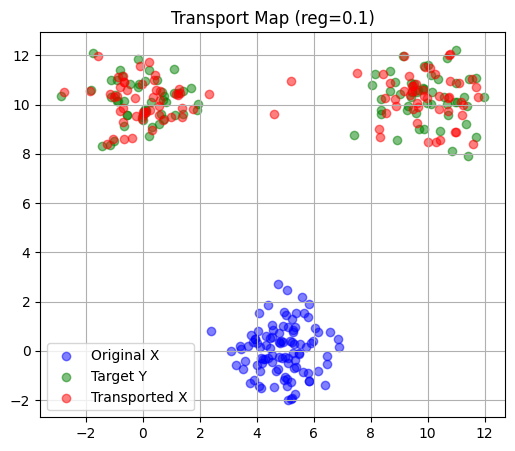


Entropic OT plan (reg=1.0)
Sinkhorn distance (reg=1.0): 63.68
Dual distance (reg=1.0): 133.79


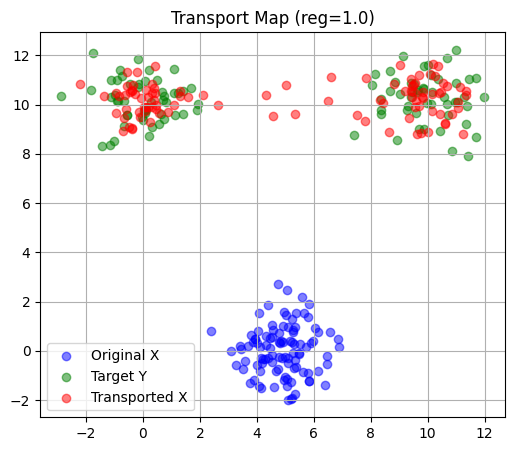


Entropic OT plan (reg=10.0)
Sinkhorn distance (reg=10.0): 55.10
Dual distance (reg=10.0): 220.98


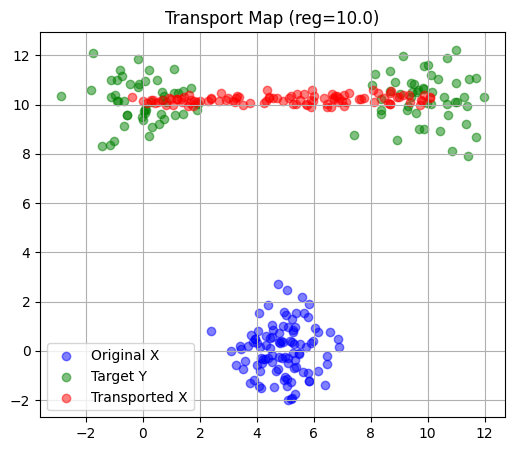

In [3]:
def sinkhorn_loss(X1, X2):
    return np.linalg.norm(X1 - X2)

reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    sink_dist = sinkhorn_loss(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    print(f"Sinkhorn distance (reg={reg}): {sink_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original X', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y', alpha=0.5)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported X', alpha=0.5)
    plt.title(f"Transport Map (reg={reg})")
    plt.legend()
    plt.grid(True)
    plt.show()


## ICNN

Epoch 0, Loss: 77.7784
Epoch 100, Loss: 13.5172
Epoch 200, Loss: 13.5044
Epoch 300, Loss: 13.4266
Epoch 400, Loss: 13.3981
Epoch 500, Loss: 13.3896
Epoch 600, Loss: 13.3960
Epoch 700, Loss: 13.3814
Epoch 800, Loss: 13.3912
Epoch 900, Loss: 13.3873


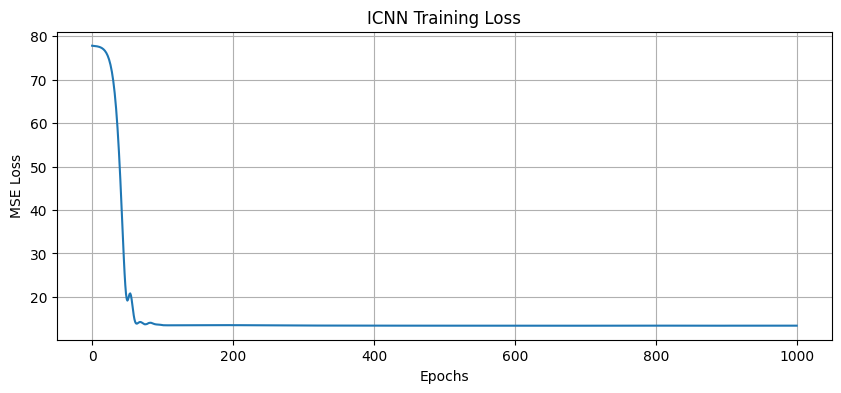

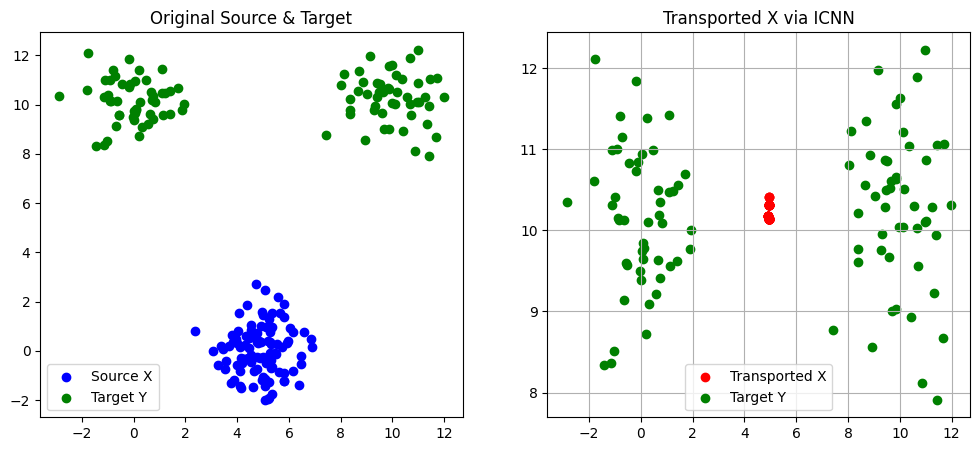

In [4]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.svm import SVC


# Create Gaussian blobs
X, labels_X = make_blobs(n_samples=100, centers=[[5, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[10, 10], [0, 10]], cluster_std=1.0, random_state=24)

# Custom ICNN class with layer configurability
class ICNN:
    def __init__(self, input_dim, hidden_layers):
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers  # List like [64, 64, 64, 64]
        self.params = self.init_params()

    def init_params(self):
        """Initialize the weights and biases for the ICNN."""
        key = jax.random.PRNGKey(0)
        keys = jax.random.split(key, num=len(self.hidden_layers) + 1)

        params = []
        prev_dim = 0  # For the Z-to-Z weight (only on hidden activations)
        for i, hidden_dim in enumerate(self.hidden_layers):
            # Input-to-hidden weights (must be non-negative to maintain convexity)
            W_x = jax.random.uniform(keys[i], (self.input_dim, hidden_dim)) * 0.01
            W_z = jax.random.normal(keys[i], (prev_dim, hidden_dim)) * 0.01 if i > 0 else None
            b = jnp.zeros((hidden_dim,))
            params.append({'W_x': jnp.abs(W_x), 'W_z': W_z, 'b': b})
            prev_dim = hidden_dim

        # Final layer (fully connected to output)
        W_final = jax.random.normal(keys[-1], (prev_dim, 1)) * 0.01
        b_final = jnp.zeros((1,))
        params.append({'W_final': W_final, 'b_final': b_final})

        return params

    def forward(self, x, params):
        """Forward pass through ICNN."""
        z = jnp.zeros((x.shape[0],))  # Initial activation
        for i, layer in enumerate(params[:-1]):
            x_proj = jnp.dot(x, layer['W_x'])  # input-to-hidden
            z_proj = jnp.dot(z, layer['W_z']) if layer['W_z'] is not None else 0
            z = jax.nn.relu(x_proj + z_proj + layer['b'])  # Convex + activation

        # Final output layer
        output = jnp.dot(z, params[-1]['W_final']) + params[-1]['b_final']
        return output

    def loss(self, params, X, Y):
        """Mean squared error between transported and target samples."""
        transported_X = self.transport(X, params)
        return jnp.mean((transported_X - Y)**2)

    def transport(self, X, params):
        """Transport map (can be approximated as the gradient of the convex potential)."""
        grad_fn = jax.vmap(jax.grad(lambda x: self.forward(x[None, :], params).squeeze()))
        return grad_fn(X)


# Instantiate ICNN with 4 hidden layers of size 64 each
icnn = ICNN(input_dim=2, hidden_layers=[64, 64, 64, 64])

# Optimizer
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(icnn.params)

# Training loop
num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    loss, grads = jax.value_and_grad(icnn.loss)(icnn.params, X, Y)
    updates, opt_state = optimizer.update(grads, opt_state)
    icnn.params = optax.apply_updates(icnn.params, updates)
    losses.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("ICNN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# Transport X using the trained ICNN
transported_X = icnn.transport(X, icnn.params)

# Plot before and after transport
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Source X')
plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y')
plt.title("Original Source & Target")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported X')
plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y')
plt.title("Transported X via ICNN")
plt.legend()
plt.grid(True)
plt.show()

# # Train classifier on transported data
# clf = SVC()
# clf.fit(transported_X, labels_X)
# predicted_labels = clf.predict(Y)

# print(f"Accuracy: {accuracy_score(labels_Y, predicted_labels):.2f}")
# print(f"Balanced Accuracy: {balanced_accuracy_score(labels_Y, predicted_labels):.2f}")
